<a href="https://colab.research.google.com/github/Zain056/neurofive-ml-task1/blob/main/Titanic_EDA_Task_Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('train.csv')

In [8]:
# 1. Fill missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Drop the 'Cabin' column because ~77% of its data is missing
df = df.drop(columns=['Cabin'])

# 3. Drop rows where 'Embarked' is missing (only 2 rows)
df = df.dropna(subset=['Embarked'])

# Verify that there are no more missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Handling Missing Values Justification:**

1. Age: I used fillna() with the median because it is a numerical column, and the median is more robust against outliers than the mean.

2. Cabin: I dropped this column entirely because the vast majority of the data is missing, making it unusable for general modeling without heavy feature engineering.

3. Embarked: I used dropna() because only 2 rows were missing out of 891. Dropping these two rows results in a negligible loss of data.

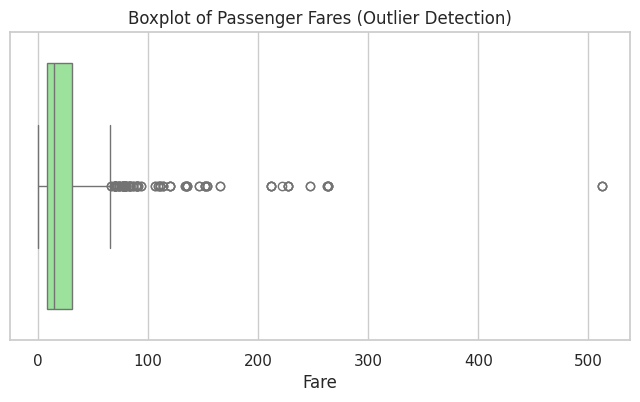

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'], color='lightgreen')
plt.title('Boxplot of Passenger Fares (Outlier Detection)')
plt.show()

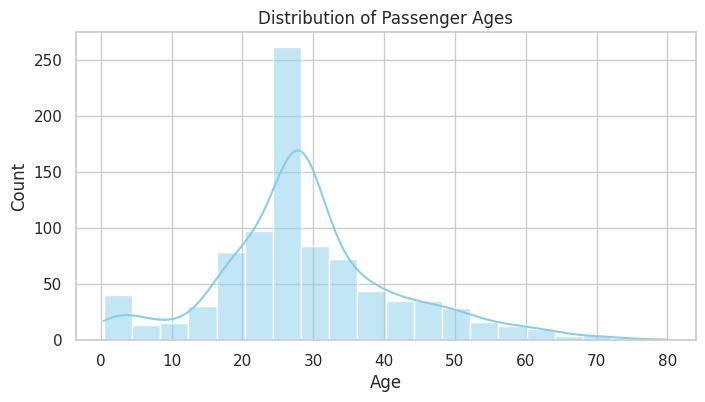

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1471/1048143988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')


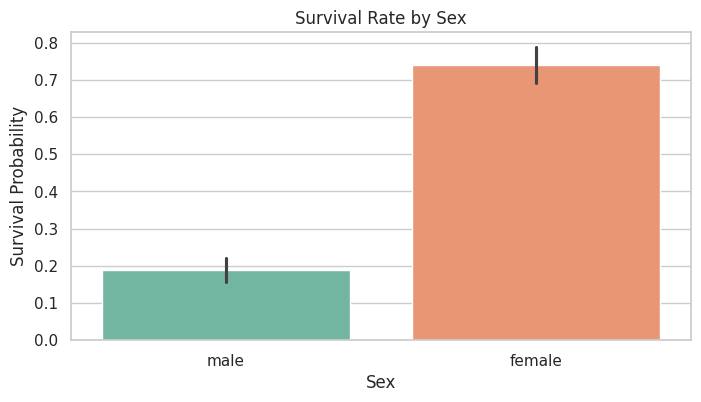

In [11]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Probability')
plt.show()

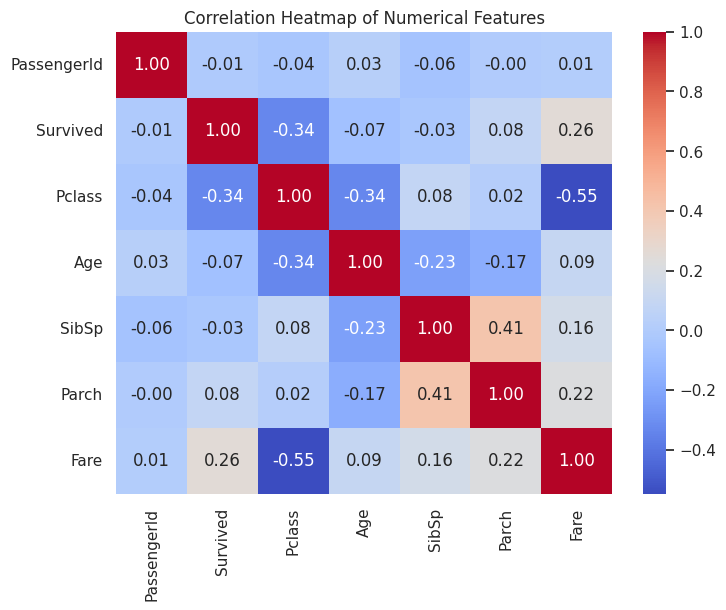

In [12]:
plt.figure(figsize=(8, 6))
# Select only numerical columns for the correlation matrix
numeric_df = df.select_dtypes(include=['number'])

# Create the heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Which feature do you think most affects survival, and why?**
Based on the visualizations, **Sex** appears to be the most dominant feature affecting survival. The bar chart clearly shows that females had a drastically higher survival rate than males, which aligns with the historical "women and children first" protocol during the Titanic's evacuation.

Looking at the numerical data in the correlation heatmap,**Pclass (Ticket Class)** is the strongest numeric factor. It has a strong negative correlation with survival (-0.34), meaning that lower class numbers (1st class) had much higher survival rates than higher class numbers (3rd class).